# Лабораторная 2

Реализовать с помощью `Numpy` класс `MyMLP`, моделирующий работу полносвязной нейронной сети.

Реализуемый класс должен

1. Поддерживать создание любого числа слоев с любым числом нейронов. Тип инициализации весов не регламентируется.
2. Обеспечивать выбор следующих функции активации в рамках каждого слоя: `ReLU`, `sigmoid`, `linear`.
3. Поддерживать решение задачи классификации и регрессии (выбор соответствующего лосса, в том числе для задачи многоклассовой классификации).
4. В процессе обучения использовать самостоятельно реализованный механизм обратного распространения (вывод формул в формате markdown) для применения градиентного и стохастического градиентного спусков (с выбором размера батча)
5. Поддерживать использование `l1`, `l2` и `l1l2` регуляризаций.

Самостоятельно выбрать наборы данных (классификация и регрессия). Провести эксперименты (различные конфигурации сети: количество слоев, нейронов, функции активации, скорость обучения и тп. — минимум 5 различных конфигураций) и сравнить результаты работы (оценка качества модели + время обучения и инференса) реализованного класса `MyMLP` со следующими моделям (в одинаковых конфигурациях):

*   MLPClassifier/MLPRegressor из sklearn
*   TensorFlow
*   Keras
*   PyTorch

Результат представить в виде .ipynb блокнота, содержащего весь необходимый код и визуализации сравнения реализаций для рассмотренных конфигураций.


# Решение

### Импорт

In [18]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings("ignore")
np.random.seed(42)

tf.random.set_seed(42)
torch.manual_seed(42)
device_torch = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Вывод формул

#### **Функции потерь**

MSE:
$$
\mathcal{L}_{MSE} = \frac{1}{2m}\sum_{i=1}^{m}(\hat{y}_i - y_i)^2
$$

Softmax:
$$
\hat{y}_{ik} = \frac{e^{z_{ik}}}{\sum_{j=1}^{K} e^{z_{ij}}}
$$

Cross-Entropy (многоклассовая классификация):
$$
\mathcal{L}_{CE} = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K} y_{ik}\ln \hat{y}_{ik}
$$


#### **Регуляризация**

$$
\mathcal{L}_{total} = \mathcal{L} + \frac{\lambda_{L2}}{2}\sum_l \|W^{(l)}\|_F^2 + \lambda_{L1}\sum_l \|W^{(l)}\|_1
$$

Градиенты регуляризации:

$$
\frac{\partial}{\partial W^{(l)}} \left( \frac{\lambda_{L2}}{2} \|W^{(l)}\|_F^2 \right) = \lambda_{L2} W^{(l)}
$$

$$
\frac{\partial}{\partial W^{(l)}} \left( \lambda_{L1} \|W^{(l)}\|_1 \right) = \lambda_{L1} \cdot \text{sign}(W^{(l)})
$$


#### **Алгоритм обратного распространения ошибки**

Шаг 1 — выходной слой:

Для MSE:
$$
\delta^{(L)} = \hat{y} - y
$$

Для Softmax + Cross-Entropy:
$$
\delta^{(L)} = \hat{y} - y
$$

Шаг 2 — распространение ошибки назад:

$$
\delta^{(l)} = \left(\delta^{(l+1)} {W^{(l+1)}}^{\top}\right) \odot {f^{(l)}}'(z^{(l)}), \quad l = L-1, \dots, 1
$$


Шаг 3 — градиенты:

$$
\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{1}{m}{A^{(l-1)}}^{\top} \delta^{(l)} + \lambda_{L2} W^{(l)} + \lambda_{L1} \cdot \text{sign}(W^{(l)})
$$

$$
\frac{\partial \mathcal{L}}{\partial b^{(l)}} = \frac{1}{m}\sum_{i=1}^{m} \delta_i^{(l)}
$$


#### **Градиентный спуск**

Обновление параметров:

$$
W^{(l)} \leftarrow W^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial W^{(l)}}
$$

$$
b^{(l)} \leftarrow b^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial b^{(l)}}
$$

где $\eta$ — скорость обучения (learning rate).


#### **Стохастический градиентный спуск**

В отличие от полного градиентного спуска, обновление происходит по батчам:

$$
W^{(l)} \leftarrow W^{(l)} - \eta \nabla_{W^{(l)}} \mathcal{L}_{batch}
$$

$$
b^{(l)} \leftarrow b^{(l)} - \eta \nabla_{b^{(l)}} \mathcal{L}_{batch}
$$

где $\mathcal{L}_{batch}$ — функция потерь, вычисленная на мини-батче.


#### **SGD с моментом**

Вводится "скорость" (velocity):

$$
v_W^{(l)} \leftarrow \mu v_W^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial W^{(l)}}
$$

$$
v_b^{(l)} \leftarrow \mu v_b^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial b^{(l)}}
$$

Обновление параметров:

$$
W^{(l)} \leftarrow W^{(l)} + v_W^{(l)}
$$

$$
b^{(l)} \leftarrow b^{(l)} + v_b^{(l)}
$$

где $\mu$ — коэффициент момента.


#### **Производные функций активации**

ReLU:
$$
f(x) = \max(0, x)
$$
$$
f'(x) =
\begin{cases}
1, & x > 0 \\
0, & x \le 0
\end{cases}
$$


Sigmoid:
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$
$$
\sigma'(x) = \sigma(x)(1 - \sigma(x))
$$


Linear:
$$
f(x) = x, \quad f'(x) = 1
$$

### Функции активации, выхода и градиенты активации

In [19]:
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(np.clip(z, -500, 500))
    return e / (np.sum(e, axis=1, keepdims=True) + 1e-15)


def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


def apply_act(z, name):
    if name == "relu":
        return np.maximum(0, z)
    if name == "sigmoid":
        return sigmoid(z)
    if name == "linear":
        return z
    raise ValueError("неизвестная активация: " + str(name))


def grad_act(z, a, name):
    if name == "relu":
        return (z > 0).astype(float)
    if name == "sigmoid":
        return a * (1 - a)
    if name == "linear":
        return np.ones_like(z)
    raise ValueError("неизвестная активация: " + str(name))

### Реализация класса MyMLP

In [20]:
class MyMLP:
    def __init__(
        self,
        layer_sizes,
        activations,
        task="regression",
        reg="none",
        l1=0.0,
        l2=0.0,
        learning_rate=0.01,
        batch_size=None,
        max_epochs=300,
        random_state=None,
        verbose=0,
    ):
        if len(activations) != len(layer_sizes) - 1:
            raise ValueError("число активаций должно быть на 1 меньше числа слоёв в layer_sizes")
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.task = task
        self.lr = learning_rate
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.verbose = verbose

        # регуляризация: none / l1 / l2 / l1l2
        self.l1 = float(l1)
        self.l2 = float(l2)
        if reg == "none":
            self.l1, self.l2 = 0.0, 0.0
        elif reg == "l1":
            self.l2 = 0.0
        elif reg == "l2":
            self.l1 = 0.0

        self.rng = np.random.RandomState(random_state)
        self.W = []
        self.b = []
        for i in range(len(layer_sizes) - 1):
            n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
            act = activations[i]
            if act == "relu":
                scale = np.sqrt(2.0 / n_in)
            else:
                scale = np.sqrt(1.0 / n_in)
            w = self.rng.randn(n_in, n_out) * scale
            b = np.zeros((1, n_out))
            self.W.append(w.astype(np.float64))
            self.b.append(b.astype(np.float64))

    # Прямой проход. Сохраняет в cache пару вход слоя a и линейный выход z. Нужно для обратного прохода
    def forward(self, X):
        a = np.asarray(X, dtype=np.float64)
        cache = []
        last_i = len(self.W) - 1
        for i, (W, bb) in enumerate(zip(self.W, self.b)):
            z = a @ W + bb
            cache.append((a.copy(), z.copy()))
            if i == last_i:
                if self.task == "multiclass":
                    a = softmax(z)
                elif self.task == "binary":
                    a = sigmoid(z)
                else:
                    a = z
            else:
                a = apply_act(z, self.activations[i])
        return a, cache

    # Стартовая ошибка: delta = (a_out - y) / n — это градиент MSE по выходу сети
    def backward(self, y, cache, a_out):
        n = y.shape[0]
        delta = (a_out - y) / n
        dW = [np.zeros_like(w) for w in self.W]
        db = [np.zeros_like(b) for b in self.b]
        L = len(self.W)
        for i in range(L - 1, -1, -1):
            a_prev, z = cache[i]
            dW[i] = a_prev.T @ delta
            db[i] = np.sum(delta, axis=0, keepdims=True)
            if i == 0:
                break
            zp = cache[i - 1][1]
            ap = apply_act(zp, self.activations[i - 1])
            g = grad_act(zp, ap, self.activations[i - 1])
            delta = (delta @ self.W[i].T) * g
        for i in range(L):
            if self.l1 > 0:
                dW[i] += self.l1 * np.sign(self.W[i])
            if self.l2 > 0:
                dW[i] += 2.0 * self.l2 * self.W[i]
        return dW, db

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        if self.task == "regression" and y.ndim == 1:
            y = y.reshape(-1, 1)
        n = X.shape[0]
        for ep in range(self.max_epochs):
            ind = self.rng.permutation(n)
            Xs, ys = X[ind], y[ind]
            if self.batch_size is None or self.batch_size >= n:
                batches = [np.arange(n)]
            else:
                bs = self.batch_size
                # Xs уже перемешан — берём подряд идущие строки
                batches = [np.arange(j, min(j + bs, n)) for j in range(0, n, bs)]
            for batch_idx in batches:
                xb = Xs[batch_idx]
                yb = ys[batch_idx]
                a_out, cache = self.forward(xb)
                dW, db = self.backward(yb, cache, a_out)
                for i in range(len(self.W)):
                    self.W[i] -= self.lr * dW[i]
                    self.b[i] -= self.lr * db[i]
        return self

    # Только прямой проход и возвращает сырые вероятности последнего слоя (softmax/sigmoid или линейный выход для регрессии  в зависимости от forward)
    def predict_proba(self, X):
        a, _ = self.forward(np.asarray(X, dtype=np.float64))
        return a

    # Берёт predict_proba и превращает в метки классов или числа
    def predict(self, X):
        p = self.predict_proba(X)
        if self.task == "regression":
            return p
        if self.task == "binary":
            return (p.ravel() >= 0.5).astype(int)
        return np.argmax(p, axis=1)


### Загрузка данных
Wine — классификация (3 класса), California housing — регрессия


In [21]:
wine = load_wine()
X_w, y_w = wine.data, wine.target
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_w, y_w, test_size=0.25, random_state=42, stratify=y_w
)
sc_w = StandardScaler()
X_w_train_s = sc_w.fit_transform(X_w_train)
X_w_test_s = sc_w.transform(X_w_test)

n_cls = len(np.unique(y_w))
Y_w_train = np.eye(n_cls)[y_w_train]
Y_w_test = np.eye(n_cls)[y_w_test]

cal = fetch_california_housing()
X_c, y_c = cal.data, cal.target
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)
sc_x = StandardScaler()
sc_y = StandardScaler()
X_c_train_s = sc_x.fit_transform(X_c_train)
X_c_test_s = sc_x.transform(X_c_test)
y_c_train_s = sc_y.fit_transform(y_c_train.reshape(-1, 1)).ravel()
y_c_test_s = sc_y.transform(y_c_test.reshape(-1, 1)).ravel()

print("Wine train:", X_w_train_s.shape, "классов:", n_cls)
print("California train:", X_c_train_s.shape)


Wine train: (133, 13) классов: 3
California train: (16512, 8)


### Конфигурации


In [22]:
# классификация
CLF_CFG = [
    {"name": "cfg1_mlp_small", "hidden": (16,), "acts": ("relu",), "lr": 0.05, "batch": 32, "epochs": 400, "reg": "none", "l1": 0.0, "l2": 0.0},
    {"name": "cfg2_deep_relu", "hidden": (32, 16), "acts": ("relu", "relu"), "lr": 0.03, "batch": 64, "epochs": 500, "reg": "none", "l1": 0.0, "l2": 0.0},
    {"name": "cfg3_sigmoid", "hidden": (24,), "acts": ("sigmoid",), "lr": 0.1, "batch": 16, "epochs": 600, "reg": "none", "l1": 0.0, "l2": 0.0},
    {"name": "cfg4_l2", "hidden": (40, 20), "acts": ("relu", "relu"), "lr": 0.02, "batch": 32, "epochs": 500, "reg": "l2", "l1": 0.0, "l2": 1e-4},
    {"name": "cfg5_fullbatch_l1l2", "hidden": (20, 10), "acts": ("relu", "relu"), "lr": 0.08, "batch": None, "epochs": 400, "reg": "l1l2", "l1": 1e-5, "l2": 5e-5},
]

# регрессия
REG_CFG = [
    {"name": "r_cfg1", "hidden": (32,), "acts": ("relu",), "lr": 0.01, "batch": 256, "epochs": 200, "reg": "none", "l1": 0.0, "l2": 0.0},
    {"name": "r_cfg2", "hidden": (64, 32), "acts": ("relu", "relu"), "lr": 0.005, "batch": 512, "epochs": 250, "reg": "none", "l1": 0.0, "l2": 0.0},
    {"name": "r_cfg3", "hidden": (48,), "acts": ("sigmoid",), "lr": 0.02, "batch": 128, "epochs": 300, "reg": "none", "l1": 0.0, "l2": 0.0},
    {"name": "r_cfg4", "hidden": (40, 20), "acts": ("relu", "linear"), "lr": 0.01, "batch": 256, "epochs": 250, "reg": "l2", "l1": 0.0, "l2": 1e-5},
    {"name": "r_cfg5", "hidden": (24, 16), "acts": ("relu", "relu"), "lr": 0.02, "batch": None, "epochs": 180, "reg": "l1", "l1": 1e-5, "l2": 0.0},
]


def to_sklearn_act(s):
    # у MLPClassifier одна активация на все скрытые слои — если в конфиге разные, берём relu
    return {"relu": "relu", "sigmoid": "logistic", "linear": "identity"}.get(s, "relu")


def to_keras_act(s):
    return {"relu": "relu", "sigmoid": "sigmoid", "linear": "linear"}.get(s, "relu")


def keras_kernel_reg(c):
    if c["reg"] == "none":
        return None
    if c["reg"] == "l2":
        return keras.regularizers.L2(c["l2"])
    if c["reg"] == "l1":
        return keras.regularizers.L1(c["l1"])
    if c["reg"] == "l1l2":
        return keras.regularizers.L1L2(l1=c["l1"], l2=c["l2"])
    return None


### Классификация

Ниже для каждой библиотеки свои функции


In [23]:
def run_sklearn_clf(c, X_tr, y_tr, X_te, y_te):
    act = to_sklearn_act(c["acts"][-1])
    if len(set(c["acts"])) > 1:
        act = "relu"
    alpha = c["l2"] if c["reg"] in ("l2", "l1l2") and c["l2"] > 0 else 1e-6
    bs = c["batch"] if c["batch"] is not None else min(200, len(X_tr))
    m = MLPClassifier(
        hidden_layer_sizes=c["hidden"],
        activation=act,
        solver="sgd",
        learning_rate_init=c["lr"],
        max_iter=c["epochs"],
        batch_size=bs,
        alpha=alpha,
        random_state=42,
        tol=1e-8,
        early_stopping=False,
    )
    t0 = time.perf_counter()
    m.fit(X_tr, y_tr)
    t1 = time.perf_counter()
    pred = m.predict(X_te)
    t2 = time.perf_counter()
    return accuracy_score(y_te, pred), t1 - t0, t2 - t1


def run_mymlp_clf(c, X_tr, Y_tr, X_te, y_te):
    n_in, n_out = X_tr.shape[1], Y_tr.shape[1]
    sizes = [n_in] + list(c["hidden"]) + [n_out]
    acts = list(c["acts"]) + ["linear"]
    m = MyMLP(
        sizes,
        acts,
        task="multiclass",
        reg=c["reg"],
        l1=c["l1"],
        l2=c["l2"],
        learning_rate=c["lr"],
        batch_size=c["batch"],
        max_epochs=c["epochs"],
        random_state=42,
    )
    t0 = time.perf_counter()
    m.fit(X_tr, Y_tr)
    t1 = time.perf_counter()
    pred = m.predict(X_te)
    t2 = time.perf_counter()
    return accuracy_score(y_te, pred), t1 - t0, t2 - t1


def run_keras_clf(c, X_tr, Y_tr, X_te, y_te):
    n_in, n_out = X_tr.shape[1], Y_tr.shape[1]
    reg = keras_kernel_reg(c)
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_in,)))
    for i, h in enumerate(c["hidden"]):
        model.add(layers.Dense(h, activation=to_keras_act(c["acts"][i]), kernel_regularizer=reg))
    model.add(layers.Dense(n_out, activation="softmax"))
    bs = c["batch"] or len(X_tr)
    model.compile(optimizer=keras.optimizers.SGD(learning_rate=c["lr"]), loss="categorical_crossentropy", metrics=["accuracy"])
    t0 = time.perf_counter()
    model.fit(X_tr, Y_tr, epochs=c["epochs"], batch_size=bs, verbose=0)
    t1 = time.perf_counter()
    pred = np.argmax(model(X_te, training=False).numpy(), axis=1)
    t2 = time.perf_counter()
    return accuracy_score(np.argmax(y_te, axis=1), pred), t1 - t0, t2 - t1


def run_tf_tape_clf(c, X_tr, Y_tr, X_te, y_te):
    n_in, n_out = X_tr.shape[1], Y_tr.shape[1]
    reg = keras_kernel_reg(c)
    blocks = []
    for i, h in enumerate(c["hidden"]):
        blocks.append(layers.Dense(h, activation=to_keras_act(c["acts"][i]), kernel_regularizer=reg))
    blocks.append(layers.Dense(n_out, activation=None))
    model = keras.Sequential(blocks)
    model.build((None, n_in))
    opt = keras.optimizers.SGD(learning_rate=c["lr"])
    bs = c["batch"] or len(X_tr)
    n = len(X_tr)

    @tf.function
    def train_step(xb, yb):
        with tf.GradientTape() as tape:
            logits = model(xb, training=True)
            loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(labels=yb, logits=logits))
            if model.losses:
                loss = loss + tf.add_n(model.losses)
        g = tape.gradient(loss, model.trainable_variables)
        opt.apply_gradients(zip(g, model.trainable_variables))
        return loss

    t0 = time.perf_counter()
    for _ in range(c["epochs"]):
        order = np.random.permutation(n)
        for s in range(0, n, bs):
            b = order[s : s + bs]
            train_step(tf.constant(X_tr[b], tf.float32), tf.constant(Y_tr[b], tf.float32))
    t1 = time.perf_counter()
    logits = model(tf.constant(X_te, tf.float32), training=False)
    pred = tf.argmax(tf.nn.softmax(logits), axis=1).numpy()
    t2 = time.perf_counter()
    return accuracy_score(np.argmax(y_te, axis=1), pred), t1 - t0, t2 - t1


class TorchClf(nn.Module):
    def __init__(self, n_in, hidden, acts, n_out):
        super().__init__()
        dims = [n_in] + list(hidden) + [n_out]
        self.fcs = nn.ModuleList()
        self.names = list(acts)
        for i in range(len(hidden)):
            self.fcs.append(nn.Linear(dims[i], dims[i + 1]))
        self.fc_out = nn.Linear(dims[-2], dims[-1])

    def forward(self, x):
        for i, fc in enumerate(self.fcs):
            x = fc(x)
            if self.names[i] == "relu":
                x = torch.relu(x)
            elif self.names[i] == "sigmoid":
                x = torch.sigmoid(x)
            # linear — без нелинейности
        return self.fc_out(x)


def torch_reg_penalty(net, l1, l2):
    s1 = s2 = 0.0
    for p in net.parameters():
        if p.dim() < 2:
            continue
        if l1 > 0:
            s1 = s1 + p.abs().sum()
        if l2 > 0:
            s2 = s2 + (p ** 2).sum()
    return l1 * s1 + l2 * s2


def run_torch_clf(c, X_tr, Y_tr, X_te, y_te):
    n_in, n_out = X_tr.shape[1], Y_tr.shape[1]
    net = TorchClf(n_in, c["hidden"], c["acts"], n_out).to(device_torch)
    opt = optim.SGD(net.parameters(), lr=c["lr"])
    xt = torch.tensor(X_tr, dtype=torch.float32, device=device_torch)
    yt = torch.tensor(Y_tr, dtype=torch.float32, device=device_torch)
    xte = torch.tensor(X_te, dtype=torch.float32, device=device_torch)
    bs = c["batch"] or len(X_tr)
    n = len(X_tr)
    l1 = c["l1"] if c["reg"] in ("l1", "l1l2") else 0.0
    l2 = c["l2"] if c["reg"] in ("l2", "l1l2") else 0.0
    loss_fn = nn.CrossEntropyLoss()

    t0 = time.perf_counter()
    net.train()
    for _ in range(c["epochs"]):
        perm = torch.randperm(n, device=device_torch)
        for s in range(0, n, bs):
            b = perm[s : s + bs]
            nb = b.shape[0]
            opt.zero_grad()
            logits = net(xt[b])
            loss = loss_fn(logits, yt[b].argmax(dim=1)) + (nb / n) * torch_reg_penalty(net, l1, l2)
            loss.backward()
            opt.step()
    t1 = time.perf_counter()
    net.eval()
    with torch.no_grad():
        pred = net(xte).argmax(dim=1).cpu().numpy()
    t2 = time.perf_counter()
    return accuracy_score(np.argmax(y_te, axis=1), pred), t1 - t0, t2 - t1


In [24]:
rows = []
for c in CLF_CFG:
    acc, tr, inf = run_mymlp_clf(c, X_w_train_s, Y_w_train, X_w_test_s, y_w_test)
    rows.append({"config": c["name"], "lib": "MyMLP", "acc": acc, "train_s": tr, "infer_s": inf})
    acc, tr, inf = run_sklearn_clf(c, X_w_train_s, y_w_train, X_w_test_s, y_w_test)
    rows.append({"config": c["name"], "lib": "sklearn", "acc": acc, "train_s": tr, "infer_s": inf})
    acc, tr, inf = run_tf_tape_clf(c, X_w_train_s, Y_w_train, X_w_test_s, Y_w_test)
    rows.append({"config": c["name"], "lib": "TF + tape", "acc": acc, "train_s": tr, "infer_s": inf})
    acc, tr, inf = run_keras_clf(c, X_w_train_s, Y_w_train, X_w_test_s, Y_w_test)
    rows.append({"config": c["name"], "lib": "Keras", "acc": acc, "train_s": tr, "infer_s": inf})
    acc, tr, inf = run_torch_clf(c, X_w_train_s, Y_w_train, X_w_test_s, Y_w_test)
    rows.append({"config": c["name"], "lib": "PyTorch", "acc": acc, "train_s": tr, "infer_s": inf})

df_clf = pd.DataFrame(rows)
print(df_clf)

                 config        lib       acc    train_s   infer_s
0        cfg1_mlp_small      MyMLP  0.955556   0.087767  0.000040
1        cfg1_mlp_small    sklearn  0.977778   0.133856  0.000131
2        cfg1_mlp_small  TF + tape  0.955556   0.593307  0.005576
3        cfg1_mlp_small      Keras  0.955556  10.219772  0.002543
4        cfg1_mlp_small    PyTorch  0.955556   0.595935  0.000120
5        cfg2_deep_relu      MyMLP  0.933333   0.187809  0.000045
6        cfg2_deep_relu    sklearn  0.977778   0.158359  0.000186
7        cfg2_deep_relu  TF + tape  0.977778   0.511670  0.003274
8        cfg2_deep_relu      Keras  1.000000  12.110878  0.002329
9        cfg2_deep_relu    PyTorch  0.977778   0.493793  0.000214
10         cfg3_sigmoid      MyMLP  0.977778   0.346712  0.000041
11         cfg3_sigmoid    sklearn  0.977778   0.376450  0.000150
12         cfg3_sigmoid  TF + tape  0.977778   1.455165  0.003238
13         cfg3_sigmoid      Keras  0.977778  16.500072  0.001597
14        

### Регрессия

Ниже для каждой библиотеки свои функции


In [25]:
def run_sklearn_reg(c, X_tr, y_tr, X_te, y_te):
    act = to_sklearn_act(c["acts"][-1])
    if len(set(c["acts"])) > 1:
        act = "relu"
    alpha = c["l2"] if c["reg"] in ("l2", "l1l2") and c["l2"] > 0 else 1e-6
    bs = c["batch"] if c["batch"] is not None else min(200, len(X_tr))
    m = MLPRegressor(
        hidden_layer_sizes=c["hidden"],
        activation=act,
        solver="sgd",
        learning_rate_init=c["lr"],
        max_iter=c["epochs"],
        batch_size=bs,
        alpha=alpha,
        random_state=42,
        tol=1e-8,
        early_stopping=False,
    )
    t0 = time.perf_counter()
    m.fit(X_tr, y_tr)
    t1 = time.perf_counter()
    pred = m.predict(X_te)
    t2 = time.perf_counter()
    return r2_score(y_te, pred), mean_squared_error(y_te, pred), t1 - t0, t2 - t1


def run_mymlp_reg(c, X_tr, y_tr, X_te, y_te):
    n_in = X_tr.shape[1]
    sizes = [n_in] + list(c["hidden"]) + [1]
    acts = list(c["acts"]) + ["linear"]
    m = MyMLP(
        sizes,
        acts,
        task="regression",
        reg=c["reg"],
        l1=c["l1"],
        l2=c["l2"],
        learning_rate=c["lr"],
        batch_size=c["batch"],
        max_epochs=c["epochs"],
        random_state=42,
    )
    t0 = time.perf_counter()
    m.fit(X_tr, y_tr.reshape(-1, 1))
    t1 = time.perf_counter()
    pred = m.predict(X_te).ravel()
    t2 = time.perf_counter()
    return r2_score(y_te, pred), mean_squared_error(y_te, pred), t1 - t0, t2 - t1


def run_keras_reg(c, X_tr, y_tr, X_te, y_te):
    reg = keras_kernel_reg(c)
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_tr.shape[1],)))
    for i, h in enumerate(c["hidden"]):
        model.add(layers.Dense(h, activation=to_keras_act(c["acts"][i]), kernel_regularizer=reg))
    model.add(layers.Dense(1, activation="linear"))
    bs = c["batch"] or len(X_tr)
    model.compile(optimizer=keras.optimizers.SGD(learning_rate=c["lr"]), loss="mse")
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr, epochs=c["epochs"], batch_size=bs, verbose=0)
    t1 = time.perf_counter()
    pred = model(X_te, training=False).numpy().ravel()
    t2 = time.perf_counter()
    return r2_score(y_te, pred), mean_squared_error(y_te, pred), t1 - t0, t2 - t1


def run_tf_tape_reg(c, X_tr, y_tr, X_te, y_te):
    reg = keras_kernel_reg(c)
    blocks = []
    for i, h in enumerate(c["hidden"]):
        blocks.append(layers.Dense(h, activation=to_keras_act(c["acts"][i]), kernel_regularizer=reg))
    blocks.append(layers.Dense(1, activation=None))
    model = keras.Sequential(blocks)
    model.build((None, X_tr.shape[1]))
    opt = keras.optimizers.SGD(learning_rate=c["lr"])
    bs = c["batch"] or len(X_tr)
    n = len(X_tr)

    @tf.function
    def train_step(xb, yb):
        with tf.GradientTape() as tape:
            yp = model(xb, training=True)
            loss = tf.reduce_mean(tf.square(yp - yb[:, None]))
            if model.losses:
                loss = loss + tf.add_n(model.losses)
        g = tape.gradient(loss, model.trainable_variables)
        opt.apply_gradients(zip(g, model.trainable_variables))
        return loss

    t0 = time.perf_counter()
    for _ in range(c["epochs"]):
        order = np.random.permutation(n)
        for s in range(0, n, bs):
            b = order[s : s + bs]
            train_step(tf.constant(X_tr[b], tf.float32), tf.constant(y_tr[b], tf.float32))
    t1 = time.perf_counter()
    pred = model(tf.constant(X_te, tf.float32), training=False).numpy().ravel()
    t2 = time.perf_counter()
    return r2_score(y_te, pred), mean_squared_error(y_te, pred), t1 - t0, t2 - t1


class TorchReg(nn.Module):
    def __init__(self, n_in, hidden, acts):
        super().__init__()
        dims = [n_in] + list(hidden) + [1]
        self.fcs = nn.ModuleList()
        self.names = list(acts)
        for i in range(len(hidden)):
            self.fcs.append(nn.Linear(dims[i], dims[i + 1]))
        self.fc_out = nn.Linear(dims[-2], dims[-1])

    def forward(self, x):
        for i, fc in enumerate(self.fcs):
            x = fc(x)
            if self.names[i] == "relu":
                x = torch.relu(x)
            elif self.names[i] == "sigmoid":
                x = torch.sigmoid(x)
        return self.fc_out(x)


def run_torch_reg(c, X_tr, y_tr, X_te, y_te):
    net = TorchReg(X_tr.shape[1], c["hidden"], c["acts"]).to(device_torch)
    opt = optim.SGD(net.parameters(), lr=c["lr"])
    xt = torch.tensor(X_tr, dtype=torch.float32, device=device_torch)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=device_torch).view(-1, 1)
    xte = torch.tensor(X_te, dtype=torch.float32, device=device_torch)
    bs = c["batch"] or len(X_tr)
    n = len(X_tr)
    l1 = c["l1"] if c["reg"] in ("l1", "l1l2") else 0.0
    l2 = c["l2"] if c["reg"] in ("l2", "l1l2") else 0.0

    t0 = time.perf_counter()
    net.train()
    for _ in range(c["epochs"]):
        perm = torch.randperm(n, device=device_torch)
        for s in range(0, n, bs):
            b = perm[s : s + bs]
            nb = b.shape[0]
            opt.zero_grad()
            pr = net(xt[b])
            loss = nn.functional.mse_loss(pr, yt[b]) + (nb / n) * torch_reg_penalty(net, l1, l2)
            loss.backward()
            opt.step()
    t1 = time.perf_counter()
    net.eval()
    with torch.no_grad():
        pred = net(xte).cpu().numpy().ravel()
    t2 = time.perf_counter()
    return r2_score(y_te, pred), mean_squared_error(y_te, pred), t1 - t0, t2 - t1

In [26]:
rows_r = []
for c in REG_CFG:
    r2, mse, tr, inf = run_mymlp_reg(c, X_c_train_s, y_c_train_s, X_c_test_s, y_c_test_s)
    rows_r.append({"config": c["name"], "lib": "MyMLP", "r2": r2, "mse": mse, "train_s": tr, "infer_s": inf})
    r2, mse, tr, inf = run_sklearn_reg(c, X_c_train_s, y_c_train_s, X_c_test_s, y_c_test_s)
    rows_r.append({"config": c["name"], "lib": "sklearn", "r2": r2, "mse": mse, "train_s": tr, "infer_s": inf})
    r2, mse, tr, inf = run_tf_tape_reg(c, X_c_train_s, y_c_train_s, X_c_test_s, y_c_test_s)
    rows_r.append({"config": c["name"], "lib": "TF + tape", "r2": r2, "mse": mse, "train_s": tr, "infer_s": inf})
    r2, mse, tr, inf = run_keras_reg(c, X_c_train_s, y_c_train_s, X_c_test_s, y_c_test_s)
    rows_r.append({"config": c["name"], "lib": "Keras", "r2": r2, "mse": mse, "train_s": tr, "infer_s": inf})
    r2, mse, tr, inf = run_torch_reg(c, X_c_train_s, y_c_train_s, X_c_test_s, y_c_test_s)
    rows_r.append({"config": c["name"], "lib": "PyTorch", "r2": r2, "mse": mse, "train_s": tr, "infer_s": inf})

df_reg = pd.DataFrame(rows_r)
print(df_reg)


    config        lib        r2       mse    train_s   infer_s
0   r_cfg1      MyMLP  0.677886  0.315760   1.036653  0.001349
1   r_cfg1    sklearn  0.756180  0.239011   1.588792  0.000632
2   r_cfg1  TF + tape  0.727421  0.267202   3.702870  0.003343
3   r_cfg1      Keras  0.716948  0.277468  10.290668  0.001965
4   r_cfg1    PyTorch  0.712223  0.282100   2.962956  0.000477
5   r_cfg2      MyMLP  0.669575  0.323907   3.335223  0.003343
6   r_cfg2    sklearn  0.776955  0.218645   4.662027  0.001288
7   r_cfg2  TF + tape  0.716406  0.277999   3.103643  0.005118
8   r_cfg2      Keras  0.717332  0.277092  10.138175  0.002741
9   r_cfg2    PyTorch  0.712547  0.281782   4.053573  0.000447
10  r_cfg3      MyMLP  0.681248  0.312464   4.643970  0.003222
11  r_cfg3    sklearn  0.753526  0.241612  12.277590  0.007744
12  r_cfg3  TF + tape  0.695976  0.298027   9.911905  0.003444
13  r_cfg3      Keras  0.703454  0.290697  23.722972  0.002447
14  r_cfg3    PyTorch  0.693988  0.299975   7.406221  0

### Визуализация результатов

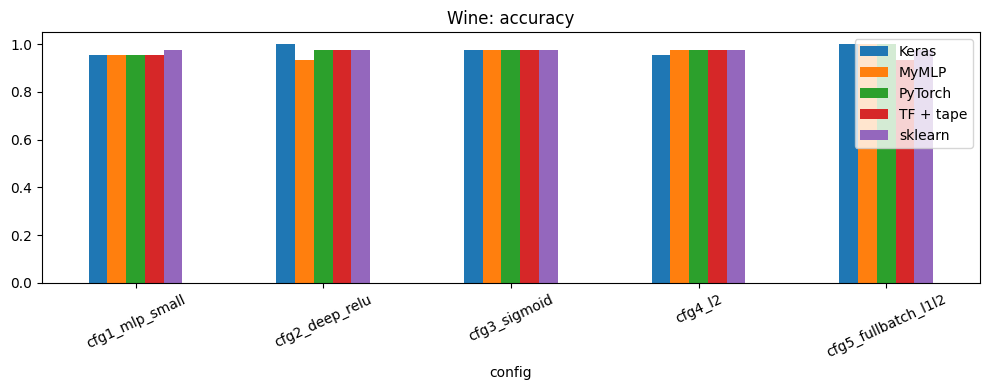

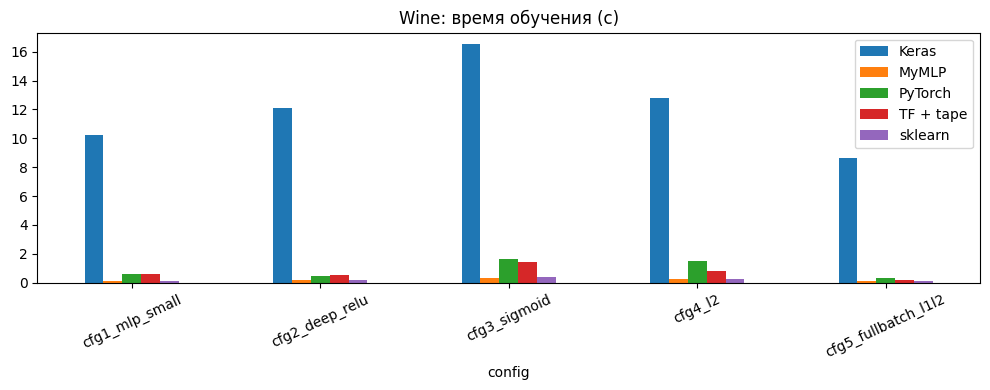

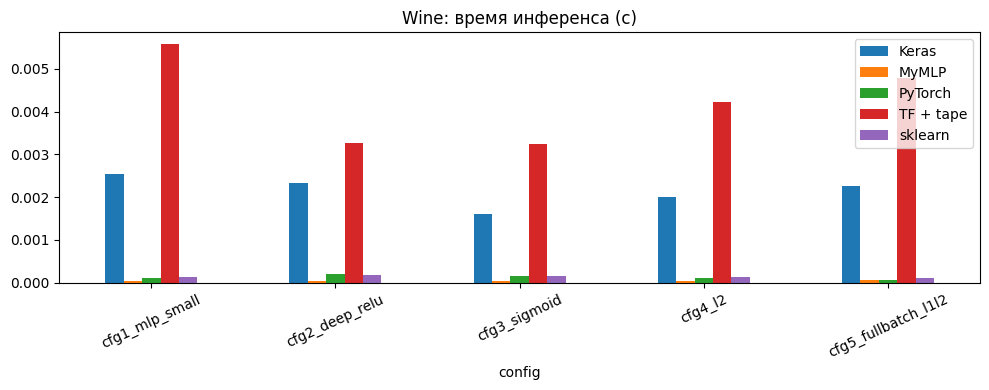

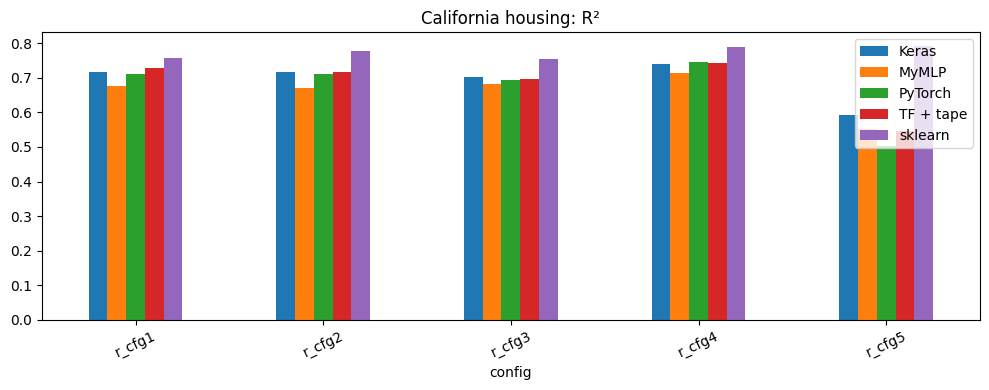

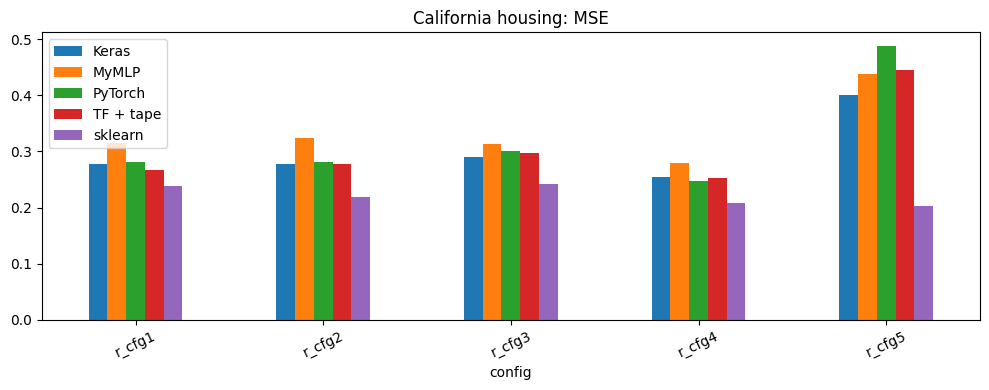

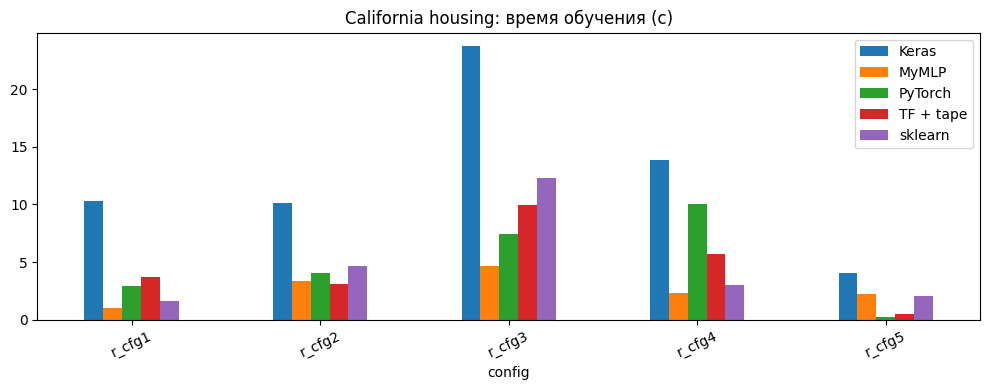

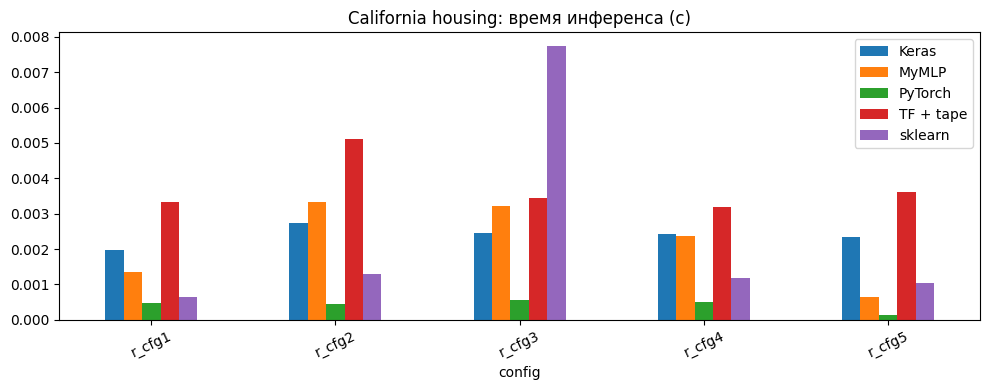

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
df_clf.pivot(index="config", columns="lib", values="acc").plot(kind="bar", ax=ax, rot=25)
ax.set_title("Wine: accuracy")
ax.legend(title="")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
df_clf.pivot(index="config", columns="lib", values="train_s").plot(kind="bar", ax=ax, rot=25)
ax.set_title("Wine: время обучения (с)")
ax.legend(title="")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
df_clf.pivot(index="config", columns="lib", values="infer_s").plot(kind="bar", ax=ax, rot=25)
ax.set_title("Wine: время инференса (с)")
ax.legend(title="")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
df_reg.pivot(index="config", columns="lib", values="r2").plot(kind="bar", ax=ax, rot=25)
ax.set_title("California housing: R²")
ax.legend(title="")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
df_reg.pivot(index="config", columns="lib", values="mse").plot(kind="bar", ax=ax, rot=25)
ax.set_title("California housing: MSE")
ax.legend(title="")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
df_reg.pivot(index="config", columns="lib", values="train_s").plot(kind="bar", ax=ax, rot=25)
ax.set_title("California housing: время обучения (с)")
ax.legend(title="")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
df_reg.pivot(index="config", columns="lib", values="infer_s").plot(kind="bar", ax=ax, rot=25)
ax.set_title("California housing: время инференса (с)")
ax.legend(title="")
plt.tight_layout()
plt.show()


### Выводы

#### Классификация

- По **accuracy** все реализации показывают схожие результаты
- Расхождения между библиотеками , например, в `cfg5_fullbatch_l1l2` у MyMLP и Keras получилось 1.00, у sklearn — 0.978, у TF + tape — 0.933 при сопоставимых гиперпараметрах, показывает чувствительность к сиду, числу эпох и тонкой настройке SGD
- **Время обучения:** у Keras заметно выше, чем у других реализаций. Вероятнее всего это связано с тем что достаточно простой датасет и более легкая реализация через Numpy с ним справляется быстрее
- **Время инференса** у всех вариантов очень маленькое и построить каких-то очевидны выводов не представляется возможным

#### Регрессия

- По **R²** все реализации показывают также схожие результаты
- **MSE** согласован с R²: чем выше R² тем ниже MSE
- **Время обучения:** снова **Keras** выделяется большими значениями 
- **Инференс** по-прежнему очень маленькие значения

#### Общий смысл для отчёта

1. **Качество:** в задаче классификации приведённые настройки выравнивают accuracy между реализациями. У регрессии MyMLP sklearn по R²/MSE, что нормально без подбора скорости обучения, инициализации и числа эпох под каждую библиотеку отдельно
2. **Производительность:** MyMLP конкурентоспособен по времени обучения на малых данных. Keras в замерах тратит существенное время на обучение. Инференс у всех быстрый, отличия на порядок малозначимы для пользователя, но видны в таблице
3. **Методология:** лабораторная подтверждает, что ручная реализация класса MyMLP даёт **сопоставимые порядки качества** с готовыми решениями при аккуратном выравнивании задачи
